Portefólio

## Exercise 1: NumPy array Indexing/Slicing

#### 1.1) In this exercise, we will use the iris dataset. Load the "iris.csv" using the appropriate method for this file type (use the new functions from the package).

In [1]:
import numpy as np
import pandas as pd
iris = pd.read_csv("C:/Users/BeaBa/Documents/GitHub/si/datasets/iris/iris.csv")

print(iris.head())


   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


#### 1.2) Select the penultimate independent variable. What is the dimension of the resulting array?

In [2]:

# Select the penultimate independent variable
penultimate_variable = iris.iloc[:, -2]

# Convert to NumPy array
penultimate_variable_array = penultimate_variable.to_numpy()

# Get the dimension of the resulting array
dimension = penultimate_variable_array.shape
print("The dimension of the penultimate variable array is:", dimension)


The dimension of the penultimate variable array is: (150,)


####  1.3) Select the last 10 samples from the iris dataset. What is the mean of the last 10 samples for each independent variable/feature?

In [3]:
# Select the last 10 samples
last_10_samples = iris.iloc[-10:, :-1]  # Exclude the label column (last column)

# Calculate the mean for each independent variable
means = last_10_samples.mean(axis=0)
print("Means of the last 10 samples for each independent variable:")
print(means)

Means of the last 10 samples for each independent variable:
sepal_length    6.45
sepal_width     3.03
petal_length    5.33
petal_width     2.17
dtype: float64


#### 1.4) Select all samples from the dataset with values less than or equal to 6 for all independent variables/features. How many samples do you obtain?

In [4]:
# Select all samples where all independent variables are ≤ 6
filtered_samples = iris.iloc[:, :-1][(iris.iloc[:, :-1] <= 6).all(axis=1)]

# Count the number of such samples
num_samples = filtered_samples.shape[0]
print("Number of samples with values ≤ 6 for all independent variables:", num_samples)


Number of samples with values ≤ 6 for all independent variables: 89


#### 1.5) Select all samples with a class/label different from 'Iris-setosa'. How many samples do you obtain?

In [5]:
# Select samples with a class/label different from 'Iris-setosa'
filtered_classes = iris[iris.iloc[:, -1] != 'Iris-setosa']

# Count the number of such samples
num_filtered_classes = filtered_classes.shape[0]
print("Number of samples with class/label different from 'Iris-setosa':", num_filtered_classes)


Number of samples with class/label different from 'Iris-setosa': 100


### Exercise 2: NumPy array Indexing/Slicing

#### 2.1) Add a method to the Dataset class that removes all samples containing at least one null value (NaN). Note that the resulting object should not contain null values in any independent feature/variable. Also, note that you should update the y vector by removing entries associated with the samples to be removed. You should use only NumPy functions. Method name: dropna

In [6]:
import numpy as np

class Dataset:
    def __init__(self, X, y):
        """
        Initialize the Dataset object.

        Parameters:
        - X: NumPy array representing the features/independent variables
        - y: NumPy array representing the target/labels
        """
        self.X = X  # Independent variables/features
        self.y = y  # Dependent variable/labels

    def dropna(self):
        """
        Removes all samples containing at least one NaN value.

        Returns:
        - self: Modified Dataset object without NaN samples
        """
        # Identify rows with no NaN values
        valid_rows = ~np.isnan(self.X).any(axis=1)  # Mask for rows without NaNs

        # Keep only valid rows in X and corresponding y values
        self.X = self.X[valid_rows]
        self.y = self.y[valid_rows]

        return self

    def fillna(self, value):
        """
        Replaces all NaN values with a given value, mean, or median of the feature.

        Parameters:
        - value: float, "mean", or "median" to replace NaN values.

        Returns:
        - self: Modified Dataset object with NaN values replaced
        """
        if value == "mean":
            # Compute column-wise mean, ignoring NaNs
            replacement = np.nanmean(self.X, axis=0)
        elif value == "median":
            # Compute column-wise median, ignoring NaNs
            replacement = np.nanmedian(self.X, axis=0)
        else:
            # Use a specific float value
            replacement = np.full(self.X.shape[1], value)

        # Replace NaN values with corresponding replacements
        nan_indices = np.isnan(self.X)
        self.X[nan_indices] = np.take(replacement, np.where(nan_indices)[1])

        return self

    def remove_by_index(self, index):
        """
        Removes a sample (row) by its index.

        Parameters:
        - index: Integer representing the index of the row to be removed.

        Returns:
        - self: Modified Dataset object with the specified sample removed
        """
        # Validate index range
        if index < 0 or index >= self.X.shape[0]:
            raise IndexError("Index out of bounds.")

        # Remove the specified row from X and y
        self.X = np.delete(self.X, index, axis=0)
        self.y = np.delete(self.y, index, axis=0)

        return self

    def __repr__(self):
        """
        String representation of the Dataset object.
        """
        return f"Dataset(X={self.X}, y={self.y})"


##### Below are some example usage scenarios for the Dataset class and its methods:

##### Dataset Initialization

In [7]:
# Example data with NaN values
X = np.array([[1, 2, np.nan], [4, 5, 6], [np.nan, 8, 9], [10, 11, 12]])
y = np.array([0, 1, 0, 1])

# Initialize the Dataset
dataset = Dataset(X, y)
print("Original Dataset:")
print(dataset)


Original Dataset:
Dataset(X=[[ 1.  2. nan]
 [ 4.  5.  6.]
 [nan  8.  9.]
 [10. 11. 12.]], y=[0 1 0 1])


#### Using dropna to Remove Rows with NaN Values

In [8]:
dataset.dropna()
print("\nDataset after dropping rows with NaN values:")
print(dataset)


Dataset after dropping rows with NaN values:
Dataset(X=[[ 4.  5.  6.]
 [10. 11. 12.]], y=[1 1])


#### Using fillna to Replace NaN Values

In [9]:
# Reset the Dataset to original (for demonstration)
X = np.array([[1, 2, np.nan], [4, 5, 6], [np.nan, 8, 9], [10, 11, 12]])
y = np.array([0, 1, 0, 1])
dataset = Dataset(X, y)

# Fill NaN values with the column mean
dataset.fillna("mean")
print("\nDataset after replacing NaN values with column mean:")
print(dataset)



Dataset after replacing NaN values with column mean:
Dataset(X=[[ 1.  2.  9.]
 [ 4.  5.  6.]
 [ 5.  8.  9.]
 [10. 11. 12.]], y=[0 1 0 1])


#### Using remove_by_index to Remove a Specific Row

In [10]:
# Remove the row at index 1
dataset.remove_by_index(1)
print("\nDataset after removing row at index 1:")
print(dataset)


Dataset after removing row at index 1:
Dataset(X=[[ 1.  2.  9.]
 [ 5.  8.  9.]
 [10. 11. 12.]], y=[0 0 1])


### Exercise 3: Implementing SelectPercentile

In [11]:
import numpy as np
import sklearn
from sklearn.feature_selection import f_classif  # Default scoring function: ANOVA F-value

class SelectPercentile:
    """
    A class for selecting the top percentile of features based on a scoring function.

    Parameters:
    - score_func: Callable, default=f_classif
        A scoring function that takes (X, y) as input and returns F-values and p-values.
    - percentile: float, default=10
        The percentile of features to select (0-100 range).

    Attributes:
    - F_: ndarray
        F-values for each feature estimated by the score_func.
    - p_: ndarray
        P-values for each feature estimated by the score_func.
    """

    def __init__(self, score_func=f_classif, percentile=10):
        self.score_func = score_func  # Scoring function (default: f_classif)
        self.percentile = percentile  # Percentile for feature selection
        self.F_ = None  # Placeholder for F-values
        self.p_ = None  # Placeholder for p-values

    def _fit(self, X, y):
        """
        Fit the SelectPercentile model to compute F and p values.

        Parameters:
        - X: ndarray of shape (n_samples, n_features)
            The input samples.
        - y: ndarray of shape (n_samples,)
            The target values.

        Returns:
        - self: Fitted SelectPercentile instance
        """
        # Validate input dimensions
        X = np.asarray(X)
        y = np.asarray(y)
        
        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")
        if y.ndim != 1:
            raise ValueError("y must be a 1D array.")

        # Calculate F-values and p-values using the scoring function
        self.F_, self.p_ = self.score_func(X, y)
        return self

    def _transform(self, X):
        """
        Transform the dataset to select features based on the percentile.

        Parameters:
        - X: ndarray of shape (n_samples, n_features)
            The input samples.

        Returns:
        - X_selected: ndarray of shape (n_samples, n_selected_features)
            Transformed dataset with selected features.
        """
        # Validate if the model has been fitted
        if self.F_ is None or self.p_ is None:
            raise RuntimeError("You must fit the model before transforming the data.")

        # Calculate the threshold F-value based on the percentile
        threshold = np.percentile(self.F_, 100 - self.percentile)
        
        # Identify features to keep (F-value >= threshold)
        mask = self.F_ >= threshold
        
        # Select and return the features
        X_selected = X[:, mask]
        return X_selected

    def fit_transform(self, X, y):
        """
        Fit the model and transform the dataset in one step.

        Parameters:
        - X: ndarray of shape (n_samples, n_features)
            The input samples.
        - y: ndarray of shape (n_samples,)
            The target values.

        Returns:
        - X_selected: ndarray of shape (n_samples, n_selected_features)
            Transformed dataset with selected features.
        """
        self._fit(X, y)
        return self._transform(X)


In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectPercentile, f_classif

# Split features (X) and labels (y)
X = iris.iloc[:, :-1].to_numpy()  # All columns except the last (features)
y = iris.iloc[:, -1].to_numpy()   # Last column (labels)

# Encode class labels as integers (necessary for f_classif)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(y)  # Convert labels to integers


In [13]:
# Initialize SelectPercentile with default score_func (f_classif) and 50% percentile
selector = SelectPercentile(percentile=50)

# Fit and transform the data
X_selected = selector.fit_transform(X, y)

# Print results
print("Original number of features:", X.shape[1])
print("Number of selected features:", X_selected.shape[1])
print("F-values for each feature:", selector.scores_)
print("P-values for each feature:", selector.pvalues_)
print("Transformed dataset (first 5 samples):")
print(X_selected[:5])



Original number of features: 4
Number of selected features: 2
F-values for each feature: [ 119.26450218   47.3644614  1179.0343277   959.32440573]
P-values for each feature: [1.66966919e-31 1.32791652e-16 3.05197580e-91 4.37695696e-85]
Transformed dataset (first 5 samples):
[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]


### Exercise 4: Implement the Cosine distance in a module called "cosine_distance.py" in the sub-package "statistics".

In [14]:
import numpy as np

def cosine_distance(x, y):
    """
    Calculate the cosine distances between a single sample and multiple samples.

    Arguments:
        x : ndarray
            A single sample as a 1D numpy array.
        y : ndarray
            Multiple samples as a 2D numpy array, where each row is a sample.

    Returns:
        distances : ndarray
            An array containing the cosine distances between x and each sample in y.
    """
    # Ensure x is a 1D array
    x = np.array(x).flatten()

    # Compute the dot product between x and all samples in y
    dot_product = np.dot(y, x)

    # Compute the magnitude (norm) of x and each row in y
    norm_x = np.linalg.norm(x)
    norm_y = np.linalg.norm(y, axis=1)

    # Compute cosine similarity
    cosine_similarity = dot_product / (norm_x * norm_y)

    # Convert similarity to distance: Distance = 1 - Similarity
    cosine_distances = 1 - cosine_similarity

    return cosine_distances


In [15]:
import numpy as np

def cosine_distance(x, y):
    """
    Calculate the cosine distances between a single sample and multiple samples.

    Arguments:
        x : ndarray
            A single sample as a 1D numpy array.
        y : ndarray
            Multiple samples as a 2D numpy array, where each row is a sample.

    Returns:
        distances : ndarray
            An array containing the cosine distances between x and each sample in y.
    """
    # Ensure x is a 1D array
    x = np.array(x).flatten()

    # Validate input dimensions
    if x.ndim != 1 or y.ndim != 2:
        raise ValueError("x must be a 1D array and y must be a 2D array.")
    if x.shape[0] != y.shape[1]:
        raise ValueError("The number of features in x and y must match.")

    # Compute the dot product between x and all samples in y
    dot_product = np.dot(y, x)

    # Compute the magnitude (norm) of x and each row in y
    norm_x = np.linalg.norm(x)
    norm_y = np.linalg.norm(y, axis=1)

    # Check for zero vectors to prevent division by zero
    if norm_x == 0:
        raise ValueError("x contains a zero vector, which is undefined for cosine distance.")
    if np.any(norm_y == 0):
        raise ValueError("y contains zero vectors, which are undefined for cosine distance.")

    # Compute cosine similarity
    cosine_similarity = dot_product / (norm_x * norm_y)

    # Clip values to avoid numerical issues
    cosine_similarity = np.clip(cosine_similarity, -1, 1)

    # Convert similarity to distance: Distance = 1 - Similarity
    cosine_distances = 1 - cosine_similarity

    return cosine_distances


In [16]:
if __name__ == "__main__":
    x = np.array([1, 2, 3])
    y = np.array([[2, 3, 4],
                  [1, 0, 1],
                  [5, 5, 5]])

    distances = cosine_distance(x, y)
    print("Cosine Distances:", distances)

Cosine Distances: [0.00741667 0.24407105 0.0741799 ]


### Exercicio 5

In [36]:
import sys
sys.path.append("C:/Users/BeaBa/Documents/GitHub/si/src/si/decomposition/pca.py")
from pca import PCA


ModuleNotFoundError: No module named 'pca'

In [ ]:
X = iris.iloc[:, :-1].values
# Instanciar o modelo PCA
pca = PCA(n_components=2)

# Ajustar e transformar os dados
X_reduced = pca.fit_transform(X)

# Imprimir os resultados
print("Dimensão original dos dados:", X.shape)
print("Dimensão após PCA:", X_reduced.shape)
print("Primeiras 5 amostras dos dados reduzidos:")
print(X_reduced[:5])

Dimensão original dos dados: (150, 4)
Dimensão após PCA: (150, 2)
Primeiras 5 amostras dos dados reduzidos:
[[ 2.68420713  0.32660731]
 [ 2.71539062 -0.16955685]
 [ 2.88981954 -0.13734561]
 [ 2.7464372  -0.31112432]
 [ 2.72859298  0.33392456]]


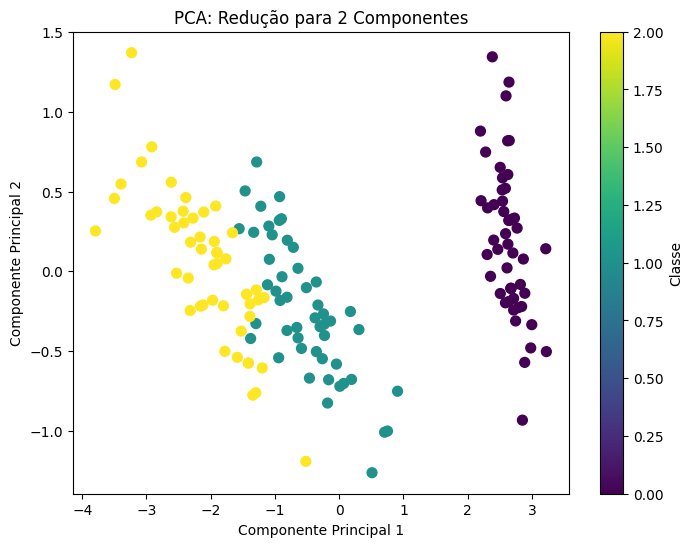

In [ ]:
import matplotlib.pyplot as plt

# Assumindo que a última coluna do dataset original contém as classes
y = iris.iloc[:, -1]

# Visualizar os dados reduzidos
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=pd.factorize(y)[0], cmap='viridis', s=50)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA: Redução para 2 Componentes")
plt.colorbar(label="Classe")
plt.show()

### Exercicio 6

In [33]:
from typing import Tuple
import numpy as np

class Dataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def shape(self):
        return self.X.shape

def stratified_train_test_split(dataset: Dataset, test_size: float = 0.2, random_state: int = 42) -> Tuple[Dataset, Dataset]:
    """
    Perform stratified splitting of the dataset into training and testing sets.

    Parameters
    ----------
    dataset: Dataset
        The dataset to split
    test_size: float
        The proportion of the dataset to include in the test split
    random_state: int
        The seed of the random number generator

    Returns
    -------
    train: Dataset
        The training dataset
    test: Dataset
        The testing dataset
    """
    # Set random state
    np.random.seed(random_state)

    # Get unique classes and their counts
    unique_classes, class_counts = np.unique(dataset.y, return_counts=True)
    train_indices = []
    test_indices = []

    # Loop through each unique class
    for cls, count in zip(unique_classes, class_counts):
        # Get indices of the current class
        cls_indices = np.where(dataset.y == cls)[0]
        # Shuffle indices
        np.random.shuffle(cls_indices)
        # Calculate the number of test samples for the current class
        n_test = int(count * test_size)
        # Split into test and train indices
        test_indices.extend(cls_indices[:n_test])
        train_indices.extend(cls_indices[n_test:])

    # Shuffle the final train and test indices
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    # Create the train and test datasets
    train = Dataset(dataset.X[train_indices], dataset.y[train_indices])
    test = Dataset(dataset.X[test_indices], dataset.y[test_indices])

    return train, test


In [34]:
import pandas as pd

# Assuming you have a DataFrame called iris
features = iris.iloc[:, :-1].values  # Extract features (X)
labels = iris.iloc[:, -1].values    # Extract labels (y)
iris_dataset = Dataset(features, labels)

# Perform stratified splitting
train, test = stratified_train_test_split(iris_dataset, test_size=0.2, random_state=42)

# Print results
print("Training set size:", train.shape())
print("Testing set size:", test.shape())

Training set size: (120, 4)
Testing set size: (30, 4)


### Exercicio 7

In [38]:
import sys 
sys.path.append("C:/Users/BeaBa/Documents/GitHub/si")

In [43]:
import sys 
sys.path.append("C:/Users/BeaBa/Documents/GitHub/si/src/si/models/knn_regressor.py")

import pandas as pd
from models.knn_regressor import KNNRegressor
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('C:/Users/BeaBa/Documents/GitHub/si/datasets/cpu/cpu.csv')

# Assume the last column is the target variable (y)
X = df.iloc[:, :-1].values  # Features (all columns except the last one)
y = df.iloc[:, -1].values   # Target (last column)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the KNNRegressor
knn = KNNRegressor(k=5)

# Fit the model on the training data
knn._fit((X_train, y_train))

# Get predictions and score the model
rmse_score = knn._score(X_test, y_test)

print(f"RMSE on the test set: {rmse_score}")


ModuleNotFoundError: No module named 'models'